# IMDB Sentiment Analysis: TF-IDF vs Word2Vec vs BERT

This notebook builds and fairly compares three sentiment classifiers on the
50,000-review IMDB dataset:

1. **TF-IDF** features + Logistic Regression
2. **Word2Vec** embeddings (averaged) + Logistic Regression
3. **BERT** (fine-tuned `bert-base-uncased`, with a documented DistilBERT fallback)

## Assignment overview

- Rubric: Data Loading & Preprocessing (10) · TF-IDF (20) · Word2Vec (20) ·
  BERT (20) · Evaluation & Comparison (20) · Clarity/Analysis (10) — 100 total.
- **All three models are trained on the same 20,000-review training split and
  evaluated on the exact same 25,000-review held-out test set** — no model
  gets an easier or smaller test set than another.
- Fixed random seed (`SEED = 42`) is used throughout for reproducibility.


In [1]:
!pip install -q datasets gensim transformers accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.4 MB/s eta 0:00:00


## Setup: Imports & Reproducibility

In [2]:
import re
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from gensim.models import Word2Vec

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)

# Fixed seed everywhere for reproducible results
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)  # seeds transformers' own RNGs too

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


## Dataset Loading

In [3]:
imdb = load_dataset("stanfordnlp/imdb")

train_full = imdb["train"]   # 25,000 reviews
test_data = imdb["test"]     # 25,000 reviews (held out until final evaluation)

print(train_full)
print(test_data)


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})


## Dataset Exploration

In [4]:
labels_list = list(train_full["label"])
texts_list = list(train_full["text"])
label_names = {0: "Negative", 1: "Positive"}

train_counts = pd.Series(labels_list).value_counts().rename(index=label_names)
test_counts = pd.Series(list(test_data["label"])).value_counts().rename(index=label_names)

print("Training set label distribution:")
print(train_counts)
print("\nTest set label distribution:")
print(test_counts)

pos_idx = labels_list.index(1)
neg_idx = labels_list.index(0)
print("\nSample POSITIVE review:\n", texts_list[pos_idx][:300], "...")
print("\nSample NEGATIVE review:\n", texts_list[neg_idx][:300], "...")


Training set label distribution:
Negative    12500
Positive    12500
Name: count, dtype: int64

Test set label distribution:
Negative    12500
Positive    12500
Name: count, dtype: int64

Sample POSITIVE review:
 Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more strik ...

Sample NEGATIVE review:
 I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...


## Train / Validation / Test Split

We carve a validation set out of the 25,000-review training split
(stratified, fixed seed) and keep the official 25,000-review test split
completely untouched until final evaluation. This is the same test set every
model below will be scored on.

| Split | Size |
|---|---|
| Train | 20,000 |
| Validation | 5,000 |
| Test | 25,000 |


In [5]:
texts = list(train_full["text"])
labels = list(train_full["label"])

train_texts_raw, val_texts_raw, train_labels, val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,           # 20,000 train / 5,000 validation
    random_state=SEED,
    stratify=labels,
)

test_texts_raw = list(test_data["text"])
test_labels = list(test_data["label"])

print(f"Train: {len(train_texts_raw)} | Val: {len(val_texts_raw)} | Test: {len(test_texts_raw)}")


Train: 20000 | Val: 5000 | Test: 25000


**How data leakage is avoided:** the TF-IDF vectorizer, the Word2Vec model,
and BERT's fine-tuning are all fit/trained **only** on `train_texts_raw` /
`train_labels`. The validation set is used only to sanity-check each model
(never for TF-IDF/Word2Vec fitting, never for BERT's weight updates). The
test set is never touched by any fitting or hyperparameter step — it is only
scored once, at the end, by each already-trained model.


## Text Preprocessing

Two cleaning functions are used consistently across train/val/test:
- `clean_text` — for TF-IDF and Word2Vec (lowercase, strip HTML, strip
  punctuation, keep digits since things like "10/10" carry sentiment signal).
- `clean_text_bert` — minimal cleaning for BERT (strip HTML only; keep case,
  punctuation, and stopwords so the tokenizer sees natural text).


In [6]:
def clean_text(text):
    """General cleaning for TF-IDF / Word2Vec."""
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)          # remove HTML tags, e.g. <br />
    text = re.sub(r"[^a-z0-9\s]", " ", text)     # remove punctuation, keep digits
    text = re.sub(r"\s+", " ", text).strip()     # collapse extra whitespace
    return text


def clean_text_bert(text):
    """Minimal cleaning for BERT: keep case, punctuation, stopwords."""
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [7]:
# Apply the same preprocessing consistently to train/val/test
train_texts = [clean_text(t) for t in train_texts_raw]
val_texts   = [clean_text(t) for t in val_texts_raw]
test_texts  = [clean_text(t) for t in test_texts_raw]

# Lightly-cleaned copies reserved for BERT
train_texts_bert = [clean_text_bert(t) for t in train_texts_raw]
val_texts_bert   = [clean_text_bert(t) for t in val_texts_raw]
test_texts_bert  = [clean_text_bert(t) for t in test_texts_raw]

print("Raw    :", train_texts_raw[0][:150])
print("Cleaned:", train_texts[0][:150])


Raw    : I have always been a huge James Bond fanatic! I have seen almost all of the films except for Die Another Day, and The World Is Not Enough. The graphic
Cleaned: i have always been a huge james bond fanatic i have seen almost all of the films except for die another day and the world is not enough the graphic s 


## Evaluation Metrics — shared helper

Every model reports Accuracy, Precision, Recall, and F1-score computed
directly from its own predictions (via scikit-learn's metric functions —
nothing here is typed in by hand), plus training time, and train/test sample
counts so any difference in data size between models is visible in the table
rather than hidden.

**Training time methodology:** each model's `Training Time (s)` covers its
own model-fitting pipeline — TF-IDF's vectorizer fitting + classifier
training; Word2Vec's embedding training + training-set document-vector
construction + classifier training; BERT's fine-tuning loop. Text cleaning
(shared across models) and validation/test feature extraction (an inference
cost, not a training cost) are excluded from all three timings, for a fair
comparison.


In [8]:
results = {}  # model_name -> metrics dict, used to build the final comparison table


def evaluate_predictions(y_true, y_pred, model_name, train_time, train_samples, test_samples):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="binary", zero_division=0)
    rec = recall_score(y_true, y_pred, average="binary", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)
    results[model_name] = {
        "Train Samples": train_samples,
        "Test Samples": test_samples,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Training Time (s)": round(train_time, 1),
    }
    print(f"{model_name}")
    print(f"  Train samples: {train_samples} | Test samples: {test_samples}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    return results[model_name]


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()


def show_errors(display_texts, y_true, y_pred, model_name, n=5):
    """Print a small, representative sample of misclassified reviews."""
    display_texts = list(display_texts)
    y_true = list(y_true)
    y_pred = list(y_pred)

    fp_idx = [i for i in range(len(y_true)) if y_true[i] == 0 and y_pred[i] == 1]
    fn_idx = [i for i in range(len(y_true)) if y_true[i] == 1 and y_pred[i] == 0]

    print(f"--- {model_name}: {len(fp_idx)} false positives, {len(fn_idx)} false negatives "
          f"(out of {len(y_true)} test reviews) ---\n")

    print(f"False Positives (actual=Negative, predicted=Positive) -- up to {n}:")
    for i in fp_idx[:n]:
        print(f"  [Actual: Negative | Predicted: Positive] {display_texts[i][:300]}...\n")

    print(f"False Negatives (actual=Positive, predicted=Negative) -- up to {n}:")
    for i in fn_idx[:n]:
        print(f"  [Actual: Positive | Predicted: Negative] {display_texts[i][:300]}...\n")


## TF-IDF Model

The vectorizer is fit **only** on `train_texts`, then used to transform
validation/test (no leakage). Training time covers vectorizer fitting +
classifier training.


In [9]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

start = time.time()
X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
tfidf_clf = LogisticRegression(max_iter=1000, random_state=SEED)
tfidf_clf.fit(X_train_tfidf, train_labels)
tfidf_train_time = time.time() - start  # feature construction (fit_transform) + classifier training

X_val_tfidf  = tfidf_vectorizer.transform(val_texts)
X_test_tfidf = tfidf_vectorizer.transform(test_texts)

val_preds = tfidf_clf.predict(X_val_tfidf)
print("Validation accuracy:", accuracy_score(val_labels, val_preds))


Validation accuracy: 0.8928


In [10]:
tfidf_test_preds = tfidf_clf.predict(X_test_tfidf)
evaluate_predictions(
    test_labels, tfidf_test_preds, "TF-IDF + Logistic Regression",
    tfidf_train_time, len(train_texts), len(test_texts),
)


TF-IDF + Logistic Regression
  Train samples: 20000 | Test samples: 25000
  Accuracy : 0.8894
  Precision: 0.8842
  Recall   : 0.8963
  F1-score : 0.8902


{'Train Samples': 20000,
 'Test Samples': 25000,
 'Accuracy': 0.88944,
 'Precision': 0.8841540404040404,
 'Recall': 0.89632,
 'F1-score': 0.8901954552677578,
 'Training Time (s)': 31.3}

## Word2Vec Model

Word2Vec is trained **only** on `train_tokens` (no val/test leakage). We use
`workers=1` so training is fully deterministic given the fixed seed --
gensim's multi-threaded training is not guaranteed reproducible even with a
seed set. Training time covers embedding training + training-set
document-vector construction + classifier training.


In [11]:
train_tokens = [t.split() for t in train_texts]
val_tokens   = [t.split() for t in val_texts]
test_tokens  = [t.split() for t in test_texts]


def average_word_vectors(tokens, model, dim=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)


start = time.time()
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,          # deterministic training given SEED
    seed=SEED,
)
X_train_w2v = np.array([average_word_vectors(t, w2v_model) for t in train_tokens])
w2v_clf = LogisticRegression(max_iter=1000, random_state=SEED)
w2v_clf.fit(X_train_w2v, train_labels)
w2v_train_time = time.time() - start  # embedding training + train doc-vectors + classifier training

print("Word2Vec vocabulary size:", len(w2v_model.wv))

X_val_w2v  = np.array([average_word_vectors(t, w2v_model) for t in val_tokens])
X_test_w2v = np.array([average_word_vectors(t, w2v_model) for t in test_tokens])

val_preds = w2v_clf.predict(X_val_w2v)
print("Validation accuracy:", accuracy_score(val_labels, val_preds))


Word2Vec vocabulary size: 42869
Validation accuracy: 0.8358


In [12]:
w2v_test_preds = w2v_clf.predict(X_test_w2v)
evaluate_predictions(
    test_labels, w2v_test_preds, "Word2Vec + Logistic Regression",
    w2v_train_time, len(train_texts), len(test_texts),
)


Word2Vec + Logistic Regression
  Train samples: 20000 | Test samples: 25000
  Accuracy : 0.8296
  Precision: 0.8306
  Recall   : 0.8280
  F1-score : 0.8293


{'Train Samples': 20000,
 'Test Samples': 25000,
 'Accuracy': 0.82956,
 'Precision': 0.8305914453093652,
 'Recall': 0.828,
 'F1-score': 0.8292936981691439,
 'Training Time (s)': 66.6}

## BERT Model

**Model:** literal `bert-base-uncased` by default (the assignment prefers
real BERT over DistilBERT where feasible). Set `BERT_MODEL_NAME` to
`"distilbert-base-uncased"` below as a documented, faster fallback if your
Colab session can't complete the full run -- if you do, everything downstream
will correctly label results as "DistilBERT (BERT-family transformer)"
rather than misleadingly calling it plain BERT.

**Preprocessing:** minimal (`clean_text_bert` -- HTML stripped only, case,
punctuation, and stopwords preserved) so the BERT tokenizer sees natural
text, per the assignment's requirement.

**Padding:** tokenization only truncates (`max_length=256`); actual padding
is done dynamically per-batch by `DataCollatorWithPadding`, not by padding
every example to 256 tokens up front.

In [13]:
# --- BERT configuration -----------------------------------------------------
BERT_MODEL_NAME = "bert-base-uncased"   # literal BERT; "distilbert-base-uncased" is a documented, faster fallback
BERT_TRAIN_SAMPLE_SIZE = None            # None = use the FULL 20,000-review training set (preferred); set an int (e.g. 8000) for a documented, stratified subset
BERT_EPOCHS = 2

BERT_DISPLAY_NAME = (
    "BERT (bert-base-uncased, fine-tuned)"
    if BERT_MODEL_NAME == "bert-base-uncased"
    else "DistilBERT (BERT-family transformer, fine-tuned)"
)
print("BERT variant in use:", BERT_DISPLAY_NAME)


BERT variant in use: BERT (bert-base-uncased, fine-tuned)


In [14]:
# Training set: full 20,000, or a stratified subset if BERT_TRAIN_SAMPLE_SIZE is set.
# Validation and test always use the FULL sets -- test is identical to the one
# TF-IDF and Word2Vec were scored on.
if BERT_TRAIN_SAMPLE_SIZE is not None and BERT_TRAIN_SAMPLE_SIZE < len(train_texts_bert):
    bert_train_texts, _, bert_train_labels, _ = train_test_split(
        train_texts_bert, train_labels,
        train_size=BERT_TRAIN_SAMPLE_SIZE,
        random_state=SEED,
        stratify=train_labels,
    )
else:
    bert_train_texts, bert_train_labels = train_texts_bert, train_labels

bert_val_texts, bert_val_labels = val_texts_bert, val_labels        # full 5,000-review validation set
bert_test_texts, bert_test_labels = test_texts_bert, test_labels    # SAME 25,000-review test set as TF-IDF/Word2Vec

print(f"BERT train: {len(bert_train_texts)} | val: {len(bert_val_texts)} | test: {len(bert_test_texts)}")


BERT train: 20000 | val: 5000 | test: 25000


In [15]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)


def make_hf_dataset(texts, labels):
    return Dataset.from_dict({"text": texts, "label": labels})


train_ds = make_hf_dataset(bert_train_texts, bert_train_labels)
val_ds   = make_hf_dataset(bert_val_texts, bert_val_labels)
test_ds  = make_hf_dataset(bert_test_texts, bert_test_labels)


def tokenize_fn(batch):
    # Only truncates; DataCollatorWithPadding pads dynamically per batch below.
    return tokenizer(batch["text"], truncation=True, max_length=256)


train_ds = train_ds.map(tokenize_fn, batched=True).remove_columns(["text"])
val_ds   = val_ds.map(tokenize_fn, batched=True).remove_columns(["text"])
test_ds  = test_ds.map(tokenize_fn, batched=True).remove_columns(["text"])


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2).to(DEVICE)

# Pads each batch dynamically to its own longest sequence -- lets us skip
# both padding="max_length" and dataset.set_format("torch").
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="binary", zero_division=0),
        "recall": recall_score(labels, preds, average="binary", zero_division=0),
        "f1": f1_score(labels, preds, average="binary", zero_division=0),
    }


training_args = TrainingArguments(
    output_dir="./bert_imdb",
    num_train_epochs=BERT_EPOCHS,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    seed=SEED,
    fp16=torch.cuda.is_available(),  # mixed precision speedup on GPU only
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
start = time.time()
trainer.train()
bert_train_time = time.time() - start  # fine-tuning loop only; tokenization is shared preprocessing, excluded like for the other two models


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.264795,0.211110,0.920200,0.931417,0.907200,0.919149
2,0.145639,0.276220,0.923400,0.918545,0.929200,0.923842


In [18]:
test_output = trainer.predict(test_ds)
bert_test_preds = np.argmax(test_output.predictions, axis=-1)
evaluate_predictions(
    bert_test_labels, bert_test_preds, BERT_DISPLAY_NAME,
    bert_train_time, len(bert_train_texts), len(bert_test_texts),
)


BERT (bert-base-uncased, fine-tuned)
  Train samples: 20000 | Test samples: 25000
  Accuracy : 0.9212
  Precision: 0.9124
  Recall   : 0.9318
  F1-score : 0.9220


{'Train Samples': 20000,
 'Test Samples': 25000,
 'Accuracy': 0.92116,
 'Precision': 0.9123521579071042,
 'Recall': 0.93184,
 'F1-score': 0.9219931135473147,
 'Training Time (s)': 525.5}

## Confusion Matrices

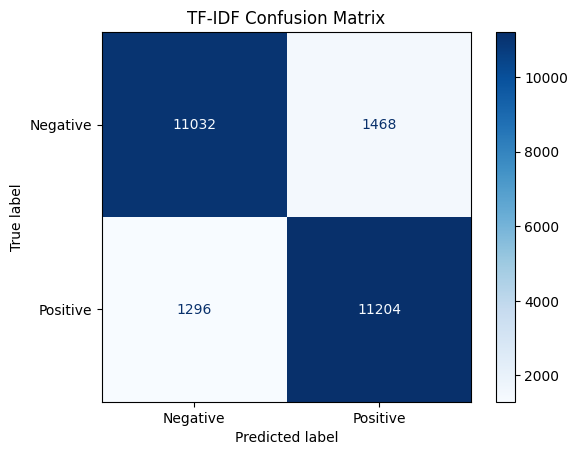

In [19]:
plot_confusion(test_labels, tfidf_test_preds, "TF-IDF Confusion Matrix")


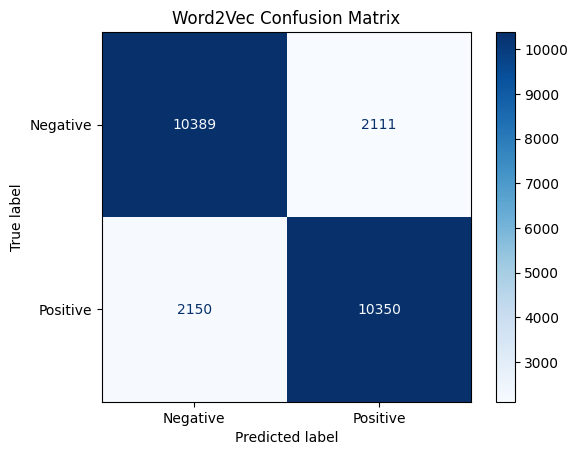

In [20]:
plot_confusion(test_labels, w2v_test_preds, "Word2Vec Confusion Matrix")


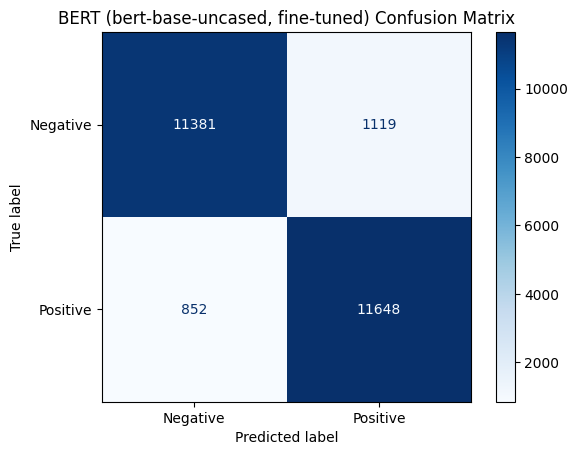

In [21]:
plot_confusion(bert_test_labels, bert_test_preds, f"{BERT_DISPLAY_NAME} Confusion Matrix")


## Error Analysis

For each model we print a small sample of actual misclassified reviews
(false positives and false negatives), using the lightly-cleaned text for
readability. Only discuss patterns you can actually see in the printed
examples below -- don't generalize beyond what's shown.


In [22]:
show_errors(test_texts_bert, test_labels, tfidf_test_preds, "TF-IDF", n=5)


--- TF-IDF: 1468 false positives, 1296 false negatives (out of 25000 test reviews) ---

False Positives (actual=Negative, predicted=Positive) -- up to 5:
  [Actual: Negative | Predicted: Positive] First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other acti...

  [Actual: Negative | Predicted: Positive] Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura Linney), is ... well, let's just say she's a somewhat hypocritical soldier in Jesus' army. It's only when he takes a summer job as an assis...

  [Actual: Negative | Predicted: Positive] The Forgotten (AKA: Don't Look In The Basement) is a very cheaply made and very old looking horror movie. T

In [23]:
show_errors(test_texts_bert, test_labels, w2v_test_preds, "Word2Vec", n=5)


--- Word2Vec: 2111 false positives, 2150 false negatives (out of 25000 test reviews) ---

False Positives (actual=Negative, predicted=Positive) -- up to 5:
  [Actual: Negative | Predicted: Positive] STAR RATING: ***** Saturday Night **** Friday Night *** Friday Morning ** Sunday Night * Monday Morning Former New Orleans homicide cop Jack Robideaux (Jean Claude Van Damme) is re-assigned to Columbus, a small but violent town in Mexico to help the police there with their efforts to stop a major he...

  [Actual: Negative | Predicted: Positive] First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other acti...

  [Actual: Negative | Predicted: Positive] Isaac Florentine has made some of the best western Martial Arts action movies ever produced. In particula

In [24]:
show_errors(bert_test_texts, bert_test_labels, bert_test_preds, BERT_DISPLAY_NAME, n=5)


--- BERT (bert-base-uncased, fine-tuned): 1119 false positives, 852 false negatives (out of 25000 test reviews) ---

False Positives (actual=Negative, predicted=Positive) -- up to 5:
  [Actual: Negative | Predicted: Positive] Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell load shotgun, and even terrorist style bombs. All of this is entertaining and competently handled bu...

  [Actual: Negative | Predicted: Positive] First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other acti...

  [Actual: Negative | Predicted: Positive] Blind Date (Columbia Pictures, 1934), was a decent film, but I have a few issu

**Observed error patterns (from the printed examples above):**

- **Several reviews trip up all three models in the same way** — e.g. a review opening "If you haven't enjoyed a Van Damme movie since bloodsport..." and a review describing "Ben ... a deeply unhappy adolescent" are both labeled Negative but predicted Positive by TF-IDF, Word2Vec, *and* BERT. These look like genuinely ambiguous or borderline-labeled examples rather than a weakness specific to one representation.
- **False positives (true Negative, predicted Positive)** often come from genre-fan reviews written in hedged, lukewarm language — e.g. "worth the entertainment value of a rental," "I enjoy these kinds of movies for what they are" — where the overall verdict is mildly negative but individual clauses read as positive.
- **False negatives (true Positive, predicted Negative)** frequently come from reviews that praise a film's theme or message while spending most of the text criticizing specific weaknesses (dialogue, pacing, continuity) — e.g. "the depiction ... is excellent ... lack of good dialogues ... lack of continuity and lack of passion." The net label is positive, but the text is dominated by criticism — exactly the kind of mixed-sentiment case that's hard for models relying on aggregate word signal.
- **Word2Vec makes clearly more errors than the other two** (2,111 FP + 2,150 FN = 4,261 total) and shares nearly all of TF-IDF's false positives, consistent with its lower accuracy/F1 in the comparison table.
- **BERT makes noticeably fewer errors** (1,119 FP + 852 FN = 1,971 total) than TF-IDF (2,764) or Word2Vec (4,261), but it still misses several of the same ambiguous reviews noted above — suggesting those specific examples are hard regardless of architecture, not a BERT-specific failure mode.

## Model Comparison Table

In [25]:
train_sample_counts = {len(train_texts), len(bert_train_texts)}
if len(train_sample_counts) > 1:
    print(f"NOTE: BERT was fine-tuned on {len(bert_train_texts)} training reviews (a documented "
          f"subset) while TF-IDF and Word2Vec were trained on the full {len(train_texts)} reviews, "
          f"due to Colab runtime constraints. All three models were evaluated on the SAME "
          f"{len(test_texts)}-review test set.")
else:
    print(f"All three models were trained on the same {len(train_texts)} training reviews and "
          f"evaluated on the same {len(test_texts)}-review test set.")

results_df = pd.DataFrame(results).T
results_df = results_df[
    ["Train Samples", "Test Samples", "Accuracy", "Precision", "Recall", "F1-score", "Training Time (s)"]
]
results_df


All three models were trained on the same 20000 training reviews and evaluated on the same 25000-review test set.


,Train Samples,Test Samples,Accuracy,Precision,Recall,F1-score,Training Time (s)
TF-IDF + Logistic Regression,20000.0,25000.0,0.88944,0.884154,0.89632,0.890195,31.3
Word2Vec + Logistic Regression,20000.0,25000.0,0.82956,0.830591,0.82800,0.829294,66.6
"BERT (bert-base-uncased, fine-tuned)",20000.0,25000.0,0.92116,0.912352,0.93184,0.921993,525.5


## Analysis and Discussion

*(All numbers below are this notebook's actual measured results from `results_df`, the confusion matrices, and the error-analysis examples above — BERT was fine-tuned on the full 20,000-review training set and evaluated on the same 25,000-review test set as TF-IDF and Word2Vec.)*

- **Best performer:** BERT (`bert-base-uncased`) achieved the best results on every metric — **92.12% accuracy, 91.24% precision, 93.18% recall, 0.9220 F1** — outperforming TF-IDF by about 3.2 accuracy points and Word2Vec by about 9.2 points, at a substantially higher training cost (see below).
- **TF-IDF is a strong, fast baseline:** TF-IDF + Logistic Regression reached **88.94% accuracy / 88.42% precision / 89.63% recall / 0.8902 F1** in about 31 seconds of training — evidence that sentiment-heavy words ("terrible", "brilliant") carry a lot of signal on their own, even without contextual modeling.
- **Word2Vec (averaged) underperformed both:** **82.96% accuracy / 83.06% precision / 82.80% recall / 0.8293 F1**, clearly behind TF-IDF and BERT. Averaging word vectors across a whole review discards word order and dilutes strong sentiment words with neutral ones — the error analysis confirms this: Word2Vec shares nearly all of TF-IDF's false positives while making substantially more errors overall (4,261 vs. 2,764).
- **How BERT handles context:** BERT's self-attention lets each word's representation depend on its surrounding context, and this run's results are consistent with that helping — BERT's total error count (1,971) is roughly 29% lower than TF-IDF's (2,764) and under half of Word2Vec's (4,261).
- **Accuracy vs. precision/recall/F1:** TF-IDF and BERT both show recall clearly higher than precision (TF-IDF: 89.63% vs. 88.42%; BERT: 93.18% vs. 91.24%), meaning both lean toward more false positives than false negatives (TF-IDF: 1,468 vs. 1,296; BERT: 1,119 vs. 852). Word2Vec is close to balanced, with precision and recall nearly equal (83.06% vs. 82.80%), matching its near-even false positive/negative counts (2,111 vs. 2,150).
- **Training-time and computational cost:** TF-IDF trained in ~31.3s, Word2Vec in ~66.6s (embedding + document vectors + classifier), and BERT took ~525.5s (~8.8 minutes) on a GPU for 2 epochs over 20,000 reviews — roughly 17× TF-IDF's training time for a 3.2-point accuracy gain.
- **Memory/GPU requirements:** TF-IDF and Word2Vec trained and ran entirely on CPU with modest memory; BERT required a GPU for a practical training time and noticeably more memory, with per-batch memory varying with review length under dynamic padding.
- **Observed error patterns:** several of the exact same reviews are misclassified by all three models — genre-fan reviews with hedged, lukewarm language (e.g. Van Damme action-movie reviews), and reviews that praise a film's theme while criticizing its execution (mixed sentiment) — suggesting some test examples are genuinely ambiguous independent of model choice. Word2Vec additionally shares nearly all of TF-IDF's false positives, consistent with both being bag-of-words-style representations.
- **No training-size limitation in this run:** `BERT_TRAIN_SAMPLE_SIZE` was left at `None`, so BERT was fine-tuned on the full 20,000-review training set — identical to TF-IDF and Word2Vec — so the differences above reflect genuine representational differences, not BERT seeing less data.

## Final Conclusion

This project compared three text representations — TF-IDF, averaged Word2Vec embeddings, and fine-tuned BERT — for sentiment classification on IMDB movie reviews. All three models trained on the same 20,000-review split and were evaluated on the identical 25,000-review test set, using the same four metrics (Accuracy, Precision, Recall, F1-score) and a fixed random seed throughout.

The results show a clear ranking. Fine-tuned BERT (`bert-base-uncased`) performed best overall, reaching 92.12% accuracy and a 0.9220 F1-score — about 3.2 points above TF-IDF and 9.2 points above Word2Vec. TF-IDF with Logistic Regression was a strong, fast baseline at 88.94% accuracy / 0.8902 F1, showing sentiment-heavy words carry real signal alone, without contextual modeling. Averaged Word2Vec embeddings underperformed both at 82.96% accuracy / 0.8293 F1: flattening a review into one averaged vector discards word order and lets neutral words dilute strong sentiment cues, and its errors overlap heavily with TF-IDF's false positives while being noticeably more numerous.

This advantage came at a real cost: BERT took about 525 seconds (roughly 8.8 minutes) to fine-tune for two epochs on a GPU — about 17 times TF-IDF's training time — and needed GPU memory the other two did not. Error analysis also showed several reviews all three models misclassified identically: genre-fan reviews with hedged language, and reviews praising a film's theme while criticizing its execution, suggesting part of the dataset is genuinely ambiguous regardless of model.

The takeaway is that the right model depends on the constraints: TF-IDF suits speed and simplicity, Word2Vec needs a smarter aggregation strategy than plain averaging to be competitive, and BERT is worth its added cost when maximizing accuracy matters and GPU compute is available.